In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )
include( "../geom.jl" )
include( "../recur.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.
Loaded geom.jl class file.
Loaded recur.jl class file.


In [2]:
# Case title.
N = 100;  μ = 1.0;  ϕ = 1/4
ξ = 0.1;  γ = 0.1;  s = 10.0/ξ^(ϕ+1);  β = 1.0;  τ = 75.0
case = "../data/results/case-1_crit-rho/"
pop1 = "N-$(N)/tau-$(round( τ, digits=6 ))/xi-$(round( ξ , digits=6 ))_spd-$(round( s, digits=6 ))/"
pop2 = "N-$(N)/beta-$(round( β, digits=6 ))/xi-$(round( ξ , digits=6 ))_spd-$(round( s, digits=6 ))/"

# Temporal variables.
T = defInt( 500 )
tlist = 0:1/2:T

# Import β data.
βlist = sort( vcat( readdlm( case*pop1*"beta-list.txt" )... ) )  # DIMENSIONAL
Nβ = length( βlist )

# Import τ data.
τlist = sort( vcat( readdlm( case*pop2*"tau-list.txt" )... ) )  # DIMENSIONAL
Nτ = length( τlist )

# Number of parameter combinations.
M = 10
println( "Important simulation data for ($(Nβ),$(Nτ)) unique parameter cases." )

# Adapatable time-step length.
ρmin = -3;  ρmax = 1
Nρ = 51;  Δρ = (ρmax - ρmin)/(Nρ-1)
ρlist = round.( 10.0.^(ρmin:Δρ:ρmax), digits=6 )  # DIMENSIONAL
println( "Each parameter case contains $(Nρ) values for ρ and $(M) replicates." )

Important simulation data for (51,51) unique parameter cases.
Each parameter case contains 51 values for ρ and 10 replicates.


In [3]:
# Generate parameter variable.
dparams = loadparams( case*"default-params.json" )
dscale = loadscale( case*"default-scale.json" )
dnondim = Nondim( dparams; scale=dscale )

# Create parameter sets.
nondim1list = [Nondim( adjparams( dparams; ρ=0.1, β=β/ξ ); scale=dscale ) for β ∈ βlist]
nondim2list = [Nondim( adjparams( dparams; ρ=0.1, τ=τ*ξ ); scale=dscale ) for τ ∈ τlist]

# Critical parameter conditions.
ρc1list = criticalρ.( nondim1list, N, μ )
ρc2list = criticalρ.( nondim2list, N, μ );

In [4]:
# Data folder name.
folder1data = [[case*pop1*"beta-$(round( β, digits=6 ))/rho-$(round( ρ, digits=6 ))/"
    for ρ ∈ ρlist] for β ∈ βlist]
folder2data = [[case*pop2*"tau-$(round( τ, digits=6 ))/rho-$(round( ρ, digits=6 ))/"
    for ρ ∈ ρlist] for τ ∈ τlist];

In [5]:
# Import activity and determinism data.
ς1datalist = [hcat( [readdlm( folder*"determinism_T-$(round( defInt, T/dscale.T )).txt" ) for folder ∈ folderlist]... )
    for folderlist ∈ folder1data];
ς2datalist = [hcat( [readdlm( folder*"determinism_T-$(round( defInt, T/dscale.T )).txt" ) for folder ∈ folderlist]... )
    for folderlist ∈ folder2data];

# Determinism statistics.
ς̄1data = [vcat( mean( ςdata, dims=1 )... ) for ςdata ∈ ς1datalist]
ς̄2data = [vcat( mean( ςdata, dims=1 )... ) for ςdata ∈ ς2datalist];

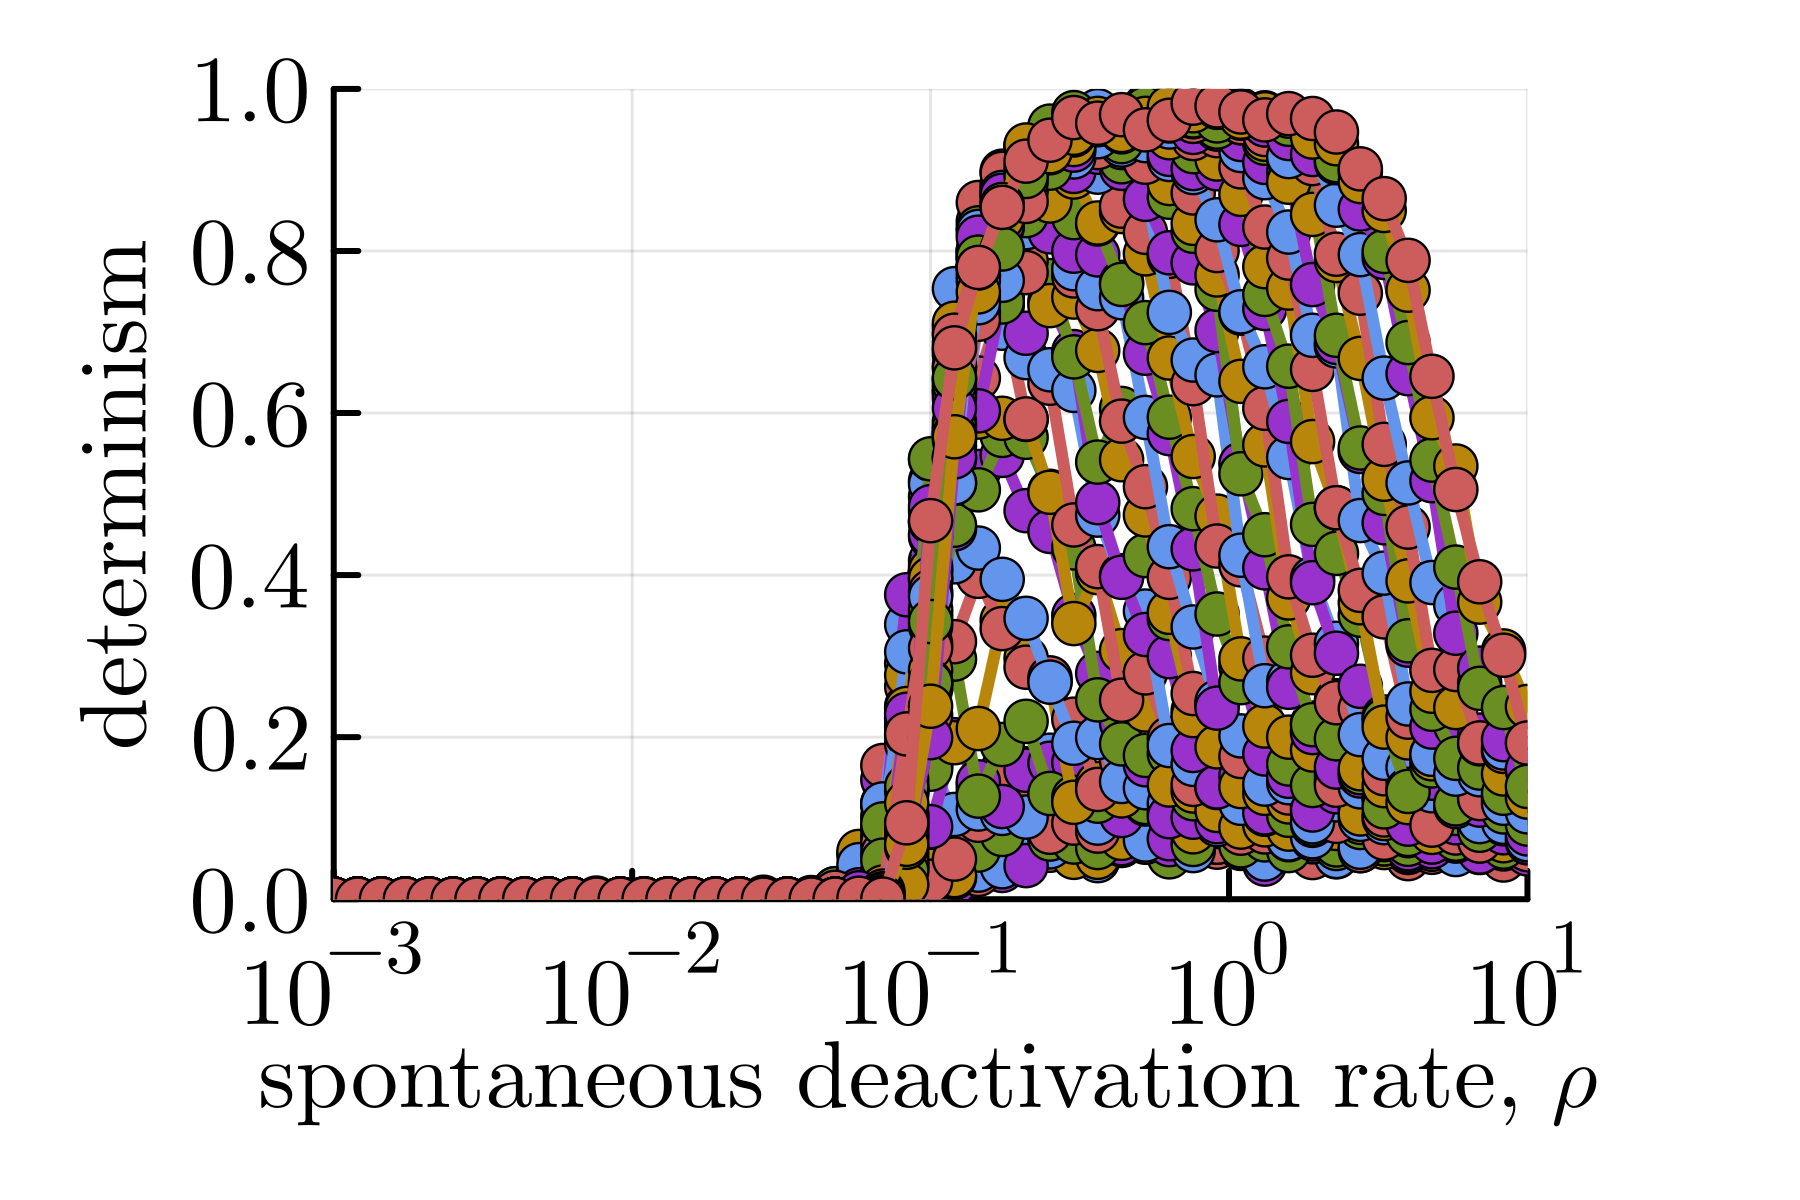

In [6]:
# Plot the determinism in each case for visual inspection.
plt = plot( size=(300,200), xformatter=:plain, dpi=600 )

for (k, ς̄list) ∈ enumerate( ς̄1data )
    plot!( plt, ρlist, ς̄list; lw=2, marker=:circ, label="" )
end

plot!( plt; xlims=(ρlist[1],ρlist[end]), xscale=:log10 )
plot!( plt; ylims=(0,1) )

plot!( plt; xlabel="spontaneous deactivation rate, "*L"ρ", ylabel="determinism", legend=:outerright )

In [7]:
# Critical ρ in default case..
ρ̂ = criticalρ( dnondim, N, μ );

# Import default determinism example.
ρ̂list = Vector{defFloat}( 10.0.^(-3:0.25:0) )  # NON-DIMENSIONAL
ς̂data = hcat( [readdlm( case*"N-$(N)/spd-$(round( dparams.s, digits=6 ) )/rho-$(round( ρ/ξ, digits=6 ))/"
    *"determinism_T-$(round( defInt, T/dscale.T )).txt" ) for ρ ∈ ρ̂list]... )

# Compute mean and standard devation.
ς̂list = vcat( mean( ς̂data, dims=1 )... )
ς̂stnd = vcat( std(  ς̂data, dims=1 )... );

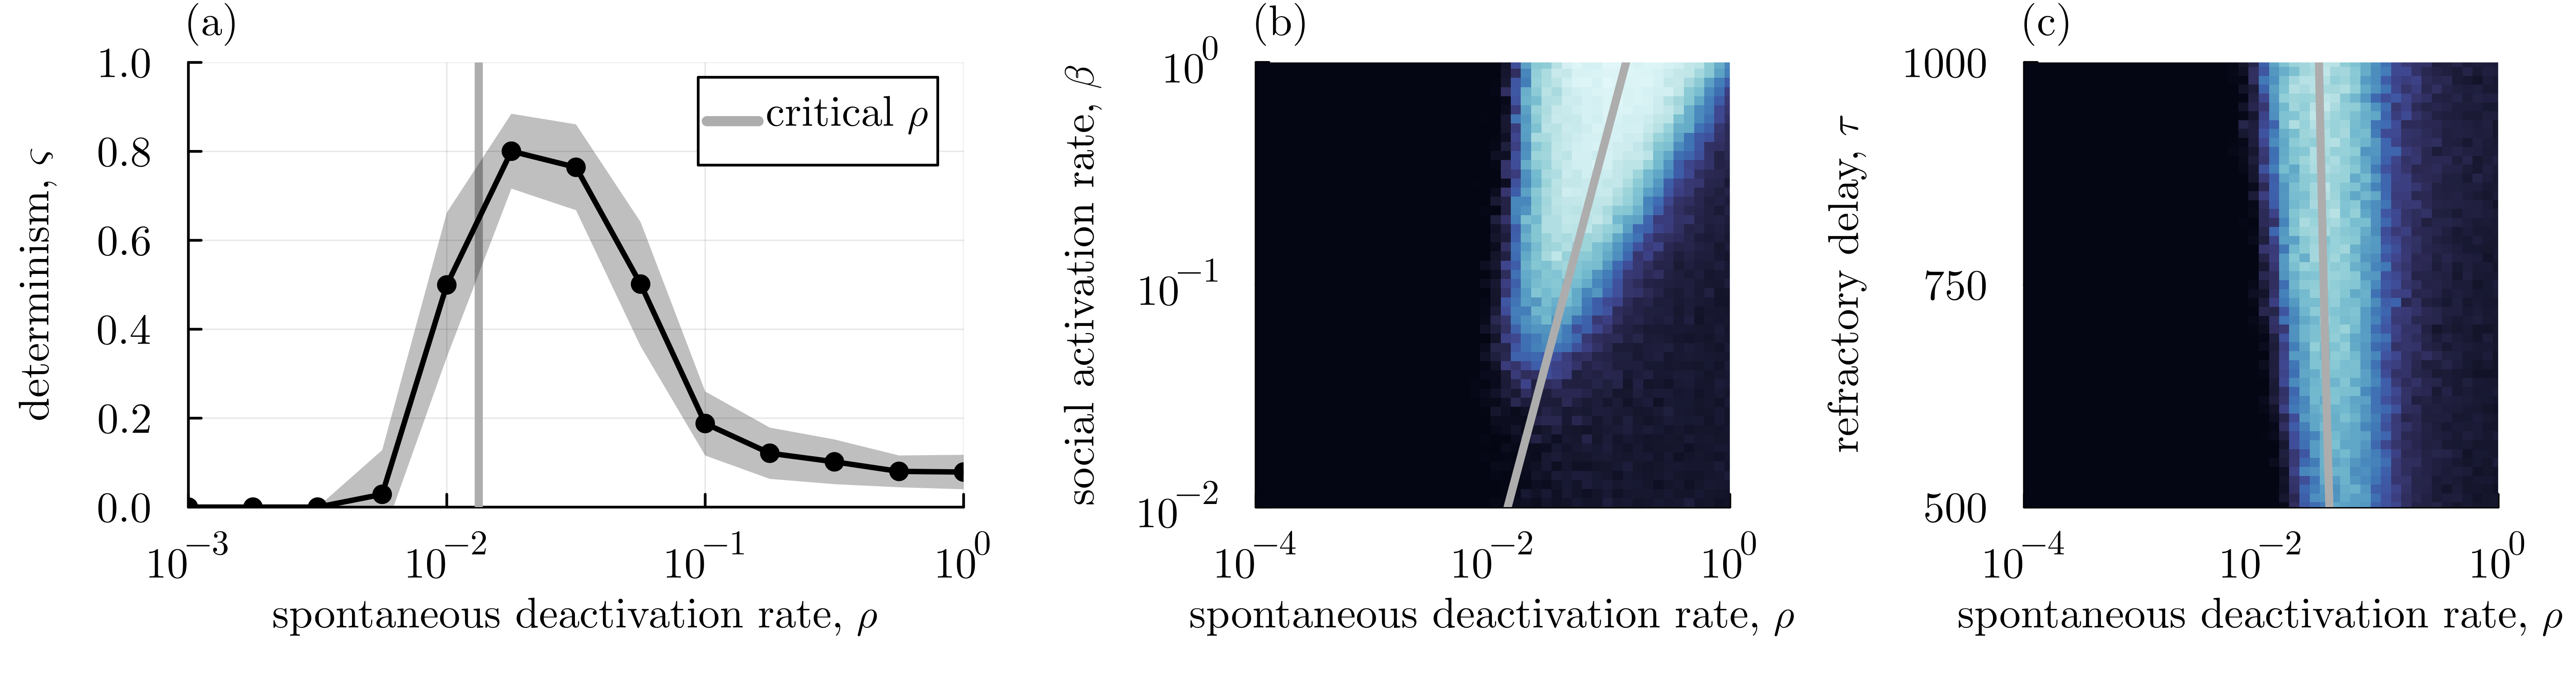

In [8]:
cmap = cgrad( :ice, [1, 2]./3, rev=false )

# Initialize plots.
plt = plot( layout=(@layout [a{0.45w} b c]), size=(950,250), xformatter=:plain, dpi=600 )
plot!( plt; left_margin=15pt, bottom_margin=25pt, right_margin=15pt )

# Plot determinism example.
plot!( plt[1], [ρ̂, ρ̂], [0,1]; color=:gray68, lw=3, label="critical "*L"ρ" )
plot!( plt[1], ρ̂list, ς̂list; ribbon=ς̂stnd, color=:black, fillalpha=1/4, lw=2, marker=:circ, label="" )

plot!( plt[1]; xlims=10.0.^[-3,0], xscale=:log10 )
plot!( plt[1]; ylims=(0,1) )

plot!( plt[1]; xlabel="spontaneous deactivation rate, "*L"ρ", ylabel="determinism, "*L"ς", legend=:topright )
title!( plt[1], "(a)"; title_position=:left )

# Plot heatmap of determinism for changing β.
heatmap!( plt[2], ξ*ρlist, ξ*βlist, hcat( ς̄1data... )'; cmap=cmap, clims=(0,1), colorbar=false )
plot!( plt[2], ρc1list, ξ*βlist; color=:gray68, lw=3, label="" )

plot!( plt[2]; xlims=(ξ*ρlist[1],ξ*ρlist[end]), xticks=10.0.^(-4:2:0), xscale=:log10 )
plot!( plt[2]; ylims=(ξ*βlist[1],ξ*βlist[end]), yticks=10.0.^(-2:1:0), yscale=:log10 )

plot!( plt[2]; xlabel="spontaneous deactivation rate, "*L"ρ", ylabel="social activation rate, "*L"β" )
title!( plt[2], "(b)"; title_position=:left )

# Plot heatmap of determinism for changing τ.
heatmap!( plt[3], ξ*ρlist, τlist/ξ, hcat( ς̄2data... )'; cmap=cmap, clims=(0,1), colorbar=false )
    # colorbar_title=text( "determinism, "*L"ς"*"\n", 10, "Computer Modern"; rotation=180 ) )
plot!( plt[3], ρc2list, τlist/ξ; color=:gray68, lw=3, label="" )

plot!( plt[3]; xlims=(ξ*ρlist[1],ξ*ρlist[end]), xticks=10.0.^(-4:2:0), xscale=:log10 )
plot!( plt[3]; ylims=(τlist[1]/ξ,τlist[end]/ξ), yticks=[50,75,100]/ξ, yscale=:linear )

plot!( plt[3]; xlabel="spontaneous deactivation rate, "*L"ρ", ylabel="refractory delay, "*L"τ" )
title!( plt[3], "(c)"; title_position=:left )

saveplot( plt, figurefolder*"determinism-vs-rho_beta-tau.png"; background=:white )

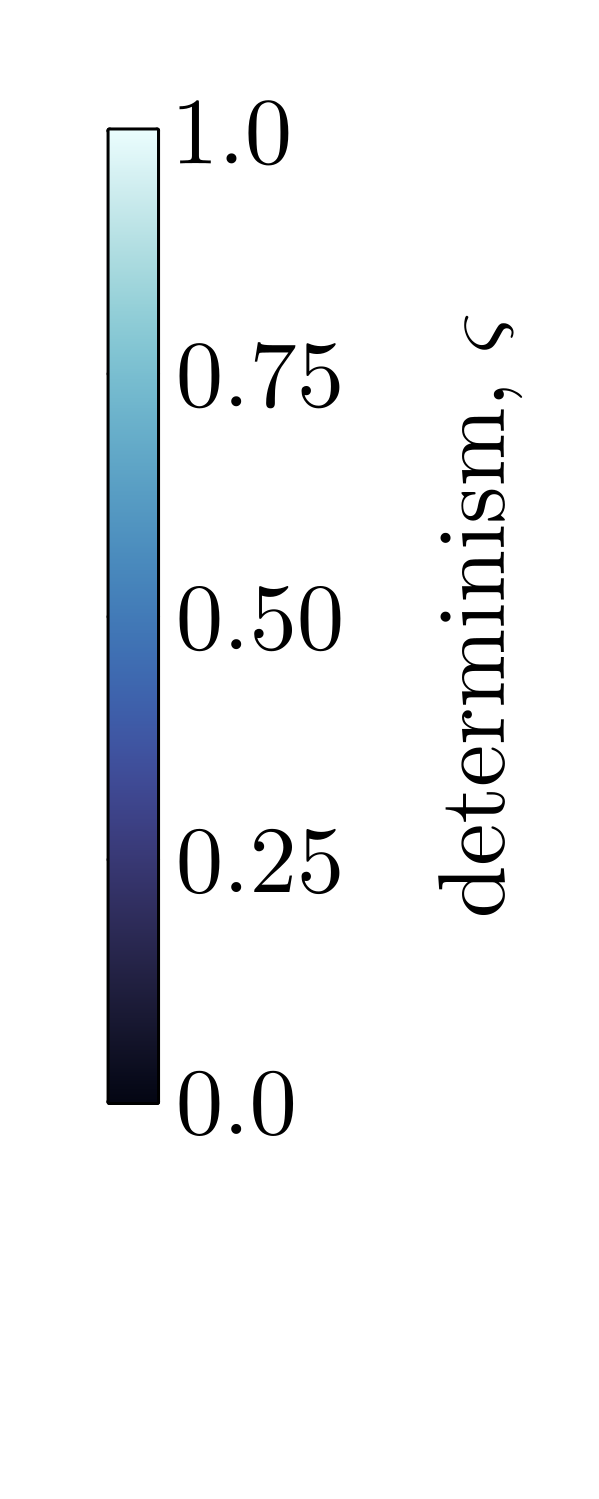

In [9]:
# Create dummy gradient data.
n = 1000
vals = reshape( range(0, 1, length=n), :, 1 )

# Plot the gradient to make colorbar.
plt = plot( size=(100,250), xformatter=:plain, dpi=600 )

plot!( plt; left_margin=7.5pt, right_margin=10pt, top_margin=10pt, bottom_margin=42pt )

heatmap!( plt, vals; c=cmap, clims=(0,1),
    colorbar=false, xtick=false, xticks=false,
    framestyle=:box, mirror=true,
    yticks=( [1, round(Int,n/4), round(Int,n/2), round(Int,3n/4), n],
              ["0.0","0.25","0.50","0.75","1.0"] ) )

plot!( plt; ylabel="\ndeterminism, "*L"ς", yguidefont=font("Computer Modern", 10, rotation=0) )

saveplot( plt, figurefolder*"determinism-vs-rho_beta-tau_colorbar.png"; background=:white )